Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

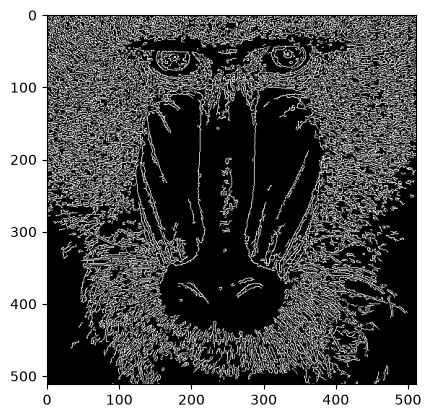

In [4]:
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()


7 [6, 12, 15, 20, 21, 88, 100]


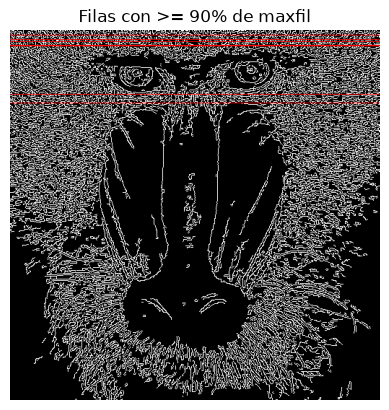

In [5]:

#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO DE PÍXELES MÁXIMOS DE LA SUMA DE PÍXELES POR FILA
maxfil = np.max(row_counts) / 255

#Normaliza en base al número de columnas, segundo valor devuelto por shape (longitud de cada fila), y al valor máximo del píxel (255)
#El resultado será la proporción de píxeles blancos por fila (entre 0 y 1)
rows = row_counts[:] / (255 * canny.shape[1])

#REALIZAMOS UN BUCLE GUARDANDO EN UN ARRAY LOS VALORES DE ROW COUNTS QUE CUMPLAN LA CONDICIÓN REQUERIDA
condition_values = []
for i, value in enumerate(row_counts):
    if value / 255 >= (0.9 * maxfil):
        condition_values.append(i)

print(len(condition_values), condition_values) #MUESTRA EL NÚMERO DE FILAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES

canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)

#DIBUJA LÍNEAS ROJAS EN LAS FILAS QUE CUMPLEN LA CONDICIÓN
for f in condition_values:
    cv2.line(canny_color, (0, f), (canny.shape[1] - 1, f), (0, 0, 255), 1)

#MUESTRA EL RESULTADO FINAL CON LAS FILAS QUE CUMPLEN LA CONDICIÓN
plt.figure()
plt.axis("off")
plt.title("Filas con >= 90% de maxfil")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))
plt.show()

TAREA 2: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

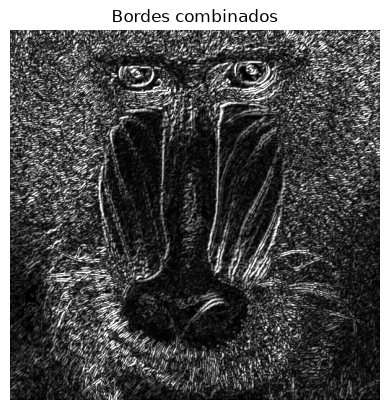

In [12]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

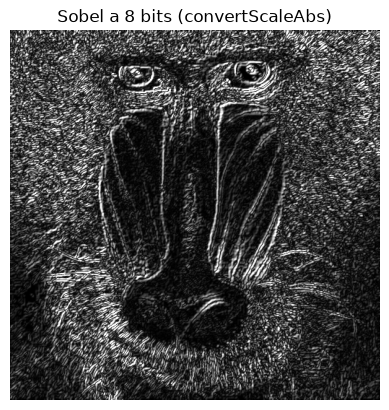

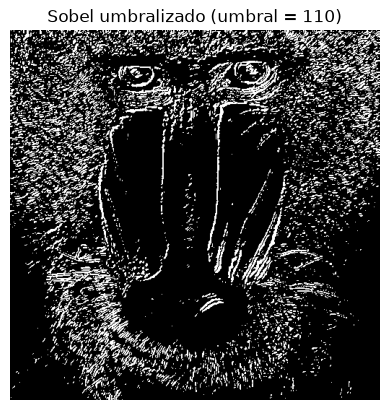

4 [3, 8, 82, 83]
5 [104, 105, 127, 287, 288]


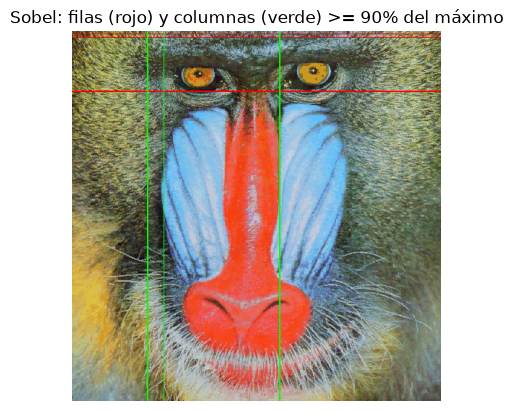

In [13]:
sobel8 = cv2.convertScaleAbs(sobel)
plt.figure()
plt.axis("off")
plt.title('Sobel a 8 bits (convertScaleAbs)')
plt.imshow(sobel8, cmap='gray')
plt.show()

#Define valor umbral
valorUmbral = 110 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

plt.figure()
plt.axis("off")
plt.title(f'Sobel umbralizado (umbral = {valorUmbral})')
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#CONTAMOS POR FILAS Y COLUMNAS
#Cuenta el número de píxeles blancos (255) por fila y columna
#Suma los valores de los pixeles por fila y columna
row_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO DE PÍXELES MÁXIMOS DE LA SUMA DE PÍXELES POR FILA Y COLUMNA
maxrow = np.max(row_counts) / 255
maxcol = np.max(col_counts) / 255

#REALIZAMOS UN BUCLE GUARDANDO EN UN ARRAY LOS VALORES DE ROW COUNTS QUE CUMPLAN LA CONDICIÓN REQUERIDA
row_values = []
for i, value in enumerate(row_counts):
    if value / 255 >= (0.9 * maxrow):
        row_values.append(i)

col_values = []
for i, value in enumerate(col_counts[0]):
    if value / 255 >= (0.9 * maxcol):
        col_values.append(i)


print(len(row_values), row_values) #MUESTRA EL NÚMERO DE FILAS Y COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES
print(len(col_values), col_values) #MUESTRA EL NÚMERO DE FILAS Y COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES


#COPIA LA IMAGEN ORIGINAL PARA DIBUJAR SOBRE ELLA
mandril_lines = img.copy()

#DIBUJA UNA LÍNEA HORIZONTAL ROJA EN CADA FILA QUE CUMPLE LA CONDICIÓN
for f in row_values:
    cv2.line(mandril_lines, (0, f), (mandril_lines.shape[1] - 1, f), (0, 0, 255), 1)

#DIBUJA UNA LÍNEA VERTICAL VERDE EN CADA COLUMNA QUE CUMPLE LA CONDICIÓN
for c in col_values:
    cv2.line(mandril_lines, (c, 0), (c, mandril_lines.shape[0] - 1), (0, 255, 0), 1)

#MUESTRA LA IMAGEN RESULTANTE (CONVERTIDA A RGB PARA QUE MATPLOTLIB MUESTRE BIEN LOS COLORES)
plt.figure()
plt.axis("off")
plt.title("Sobel: filas (rojo) y columnas (verde) >= 90% del máximo")
plt.imshow(cv2.cvtColor(mandril_lines, cv2.COLOR_BGR2RGB))
plt.show()

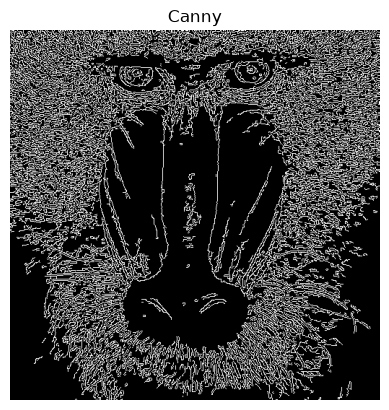

Canny maxrow: 220.0 | Filas: 7 [6, 12, 15, 20, 21, 88, 100]
Canny maxcol: 187.0 | Columnas: 19 [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]


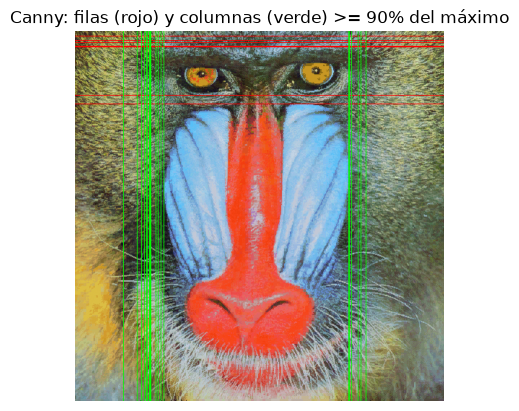

In [14]:
#CANNY YA ES BINARIA (0 O 255), ASÍ QUE NO HACE FALTA CONVERTIR NI UMBRALIZAR
plt.figure()
plt.axis("off")
plt.title('Canny')
plt.imshow(canny, cmap='gray')
plt.show()

#CONTAMOS POR FILAS Y COLUMNAS
row_counts_canny = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts_canny = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO MÁXIMO DE PÍXELES BLANCOS POR FILA Y POR COLUMNA
maxrow_canny = np.max(row_counts_canny) / 255
maxcol_canny = np.max(col_counts_canny) / 255

#GUARDAMOS LAS POSICIONES DE LAS FILAS QUE CUMPLEN LA CONDICIÓN
row_values_canny = []
for i, value in enumerate(row_counts_canny):
    if value / 255 >= (0.9 * maxrow_canny):
        row_values_canny.append(i)

#GUARDAMOS LAS POSICIONES DE LAS COLUMNAS QUE CUMPLEN LA CONDICIÓN
col_values_canny = []
for i, value in enumerate(col_counts_canny[0]):
    if value / 255 >= (0.9 * maxcol_canny):
        col_values_canny.append(i)

#MUESTRA EL MÁXIMO, EL NÚMERO DE FILAS/COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES
print("Canny maxrow:", maxrow_canny, "| Filas:", len(row_values_canny), row_values_canny)
print("Canny maxcol:", maxcol_canny, "| Columnas:", len(col_values_canny), col_values_canny)

#COPIA NUEVA DEL MANDRIL PARA NO MEZCLAR CON LAS LÍNEAS DE SOBEL
mandril_lines_canny = img.copy()

#DIBUJA UNA LÍNEA HORIZONTAL ROJA EN CADA FILA QUE CUMPLE LA CONDICIÓN
for f in row_values_canny:
    cv2.line(mandril_lines_canny, (0, f), (mandril_lines_canny.shape[1] - 1, f), (0, 0, 255), 1)

#DIBUJA UNA LÍNEA VERTICAL VERDE EN CADA COLUMNA QUE CUMPLE LA CONDICIÓN
for c in col_values_canny:
    cv2.line(mandril_lines_canny, (c, 0), (c, mandril_lines_canny.shape[0] - 1), (0, 255, 0), 1)

#MUESTRA LA IMAGEN RESULTANTE
plt.figure()
plt.axis("off")
plt.title("Canny: filas (rojo) y columnas (verde) >= 90% del máximo")
plt.imshow(cv2.cvtColor(mandril_lines_canny, cv2.COLOR_BGR2RGB))
plt.show()

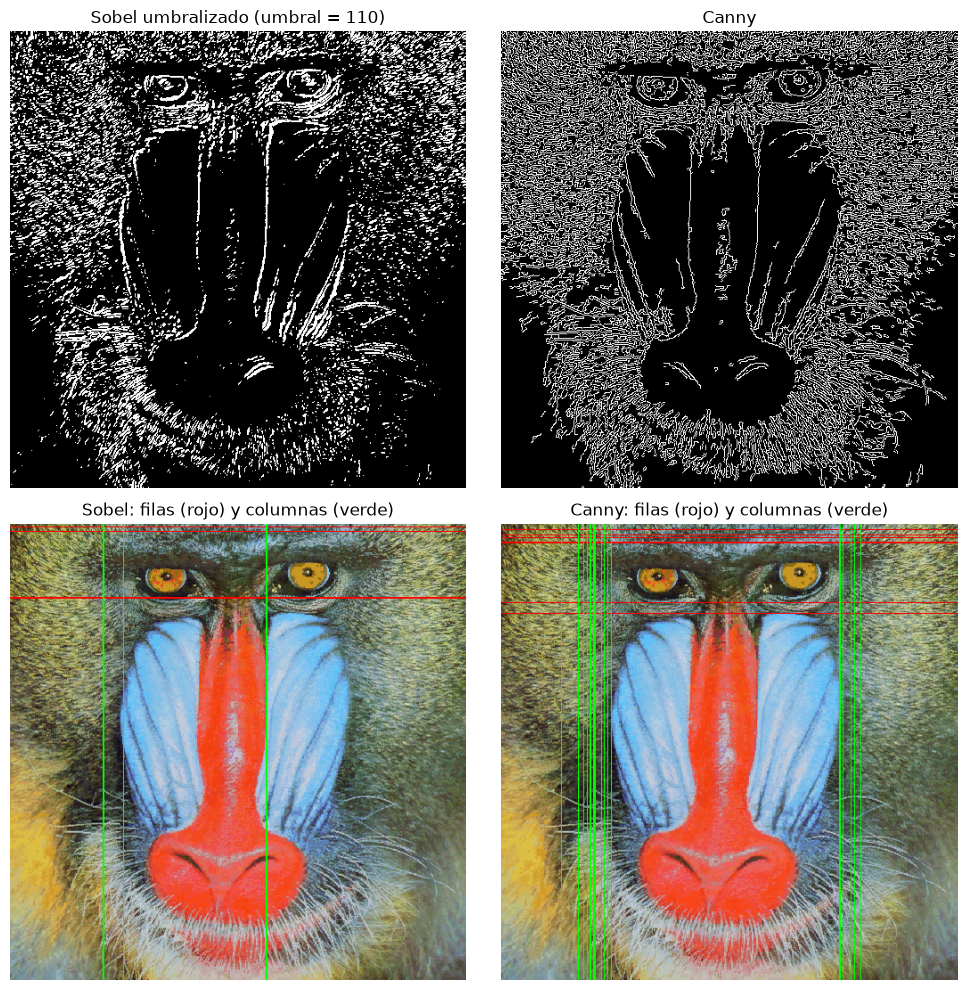

In [15]:
plt.figure(figsize=(10, 10))

#IMAGEN BINARIA DE SOBEL UMBRALIZADO
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title(f'Sobel umbralizado (umbral = {valorUmbral})')
plt.imshow(imagenUmbralizada, cmap='gray')

#IMAGEN BINARIA DE CANNY
plt.subplot(2, 2, 2)
plt.axis("off")
plt.title('Canny')
plt.imshow(canny, cmap='gray')

#MANDRIL CON LAS FILAS Y COLUMNAS SELECCIONADAS POR SOBEL
plt.subplot(2, 2, 3)
plt.axis("off")
plt.title('Sobel: filas (rojo) y columnas (verde)')
plt.imshow(cv2.cvtColor(mandril_lines, cv2.COLOR_BGR2RGB))

#MANDRIL CON LAS FILAS Y COLUMNAS SELECCIONADAS POR CANNY
plt.subplot(2, 2, 4)
plt.axis("off")
plt.title('Canny: filas (rojo) y columnas (verde)')
plt.imshow(cv2.cvtColor(mandril_lines_canny, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()

TAREA 3: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [16]:
#DEMOSTRADOR: CORTINA DE PRIVACIDAD DIGITAL (REINTERPRETACIÓN DE MY LITTLE PIECE OF PRIVACY)

vid = cv2.VideoCapture(0)

#Sustracción de fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=True)

while(True):
    #Fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Efecto espejo
        framem = cv2.flip(frame, 1)

        #MASCARA: 255 = PERSONA, 127 = SOMBRA, 0 = FONDO
        objetos = eliminadorFondo.apply(framem)

        #UMBRALIZA PARA QUITAR LAS SOMBRAS: SOLO QUEDA LO QUE VALE 255
        _, mascara = cv2.threshold(objetos, 200, 255, cv2.THRESH_BINARY)

        #CUENTA POR COLUMNAS LOS PÍXELES BLANCOS DE LA MÁSCARA
        col_counts = cv2.reduce(mascara, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

        #NÚMERO MÁXIMO DE PÍXELES BLANCOS EN UNA COLUMNA
        maxcol = np.max(col_counts) / 255

        #SOLO SE DIBUJA LA CORTINA SI HAY ALGUIEN (EVITA TAPAR TODO CON LA MÁSCARA VACÍA)
        if maxcol > 20:
            #GUARDA LAS COLUMNAS CON AL MENOS EL 90% DEL MÁXIMO
            col_values = []
            for i, value in enumerate(col_counts[0]):
                if value / 255 >= (0.3 * maxcol):       #MANTENER VALORES ENTRE 0.3 Y 0.5 PARA QUE SEA MÁS EFICAZ
                    col_values.append(i)

            #LÍMITES DE LA CORTINA: PRIMERA Y ÚLTIMA COLUMNA QUE CUMPLEN LA CONDICIÓN
            x1 = min(col_values)
            x2 = max(col_values)

            #DIBUJA LA CORTINA: RECTÁNGULO RELLENO DE ARRIBA ABAJO
            cv2.rectangle(framem, (x1, 0), (x2, framem.shape[0] - 1), (40, 40, 40), -1)

        #Muestra resultados
        cv2.imshow('Camara', framem)
        cv2.imshow('Mascara', mascara)

    #Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break

#LIBERA LA CAMARA Y DESTRUYE LAS VENTANAS
vid.release()
cv2.destroyAllWindows()